# Dataset figures

Figures D1-D11 summarize synthesis records, the training/test split, and literature coverage. In two-panel summaries, a shows synthesis records and b shows unique DOIs; numeric DOI panels use the median per DOI.

In [1]:
from pathlib import Path
import sys
import io
import csv
import hashlib
import json

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src/mofinder").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from mofinder.plotting.dataset_analysis import (
    load_records, summarize, validate_against_reference, plot_category,
    plot_property, plot_stability, generate_outputs,
)
from mofinder.plotting.condition_coverage import (
    load_conditions, summarize_coverage, validate_reference, plot_coverage,
    generate_outputs as generate_coverage_outputs,
)
from mofinder.plotting.split_embedding import (
    load_embedding, plot_embedding, generate_outputs as generate_embedding_outputs,
)

from mofinder.plotting.literature_triage_figures import (
    summarize_publishers, draw_publisher_coverage,
)

def show_plot(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=150)
    display(Image(data=buffer.getvalue(), width=720))
    plt.close(figure)

records = load_records(ROOT)
validate_against_reference(summarize(records), ROOT)
conditions = load_conditions(ROOT)
validate_reference(summarize_coverage(conditions), ROOT)
embedding = load_embedding(ROOT)

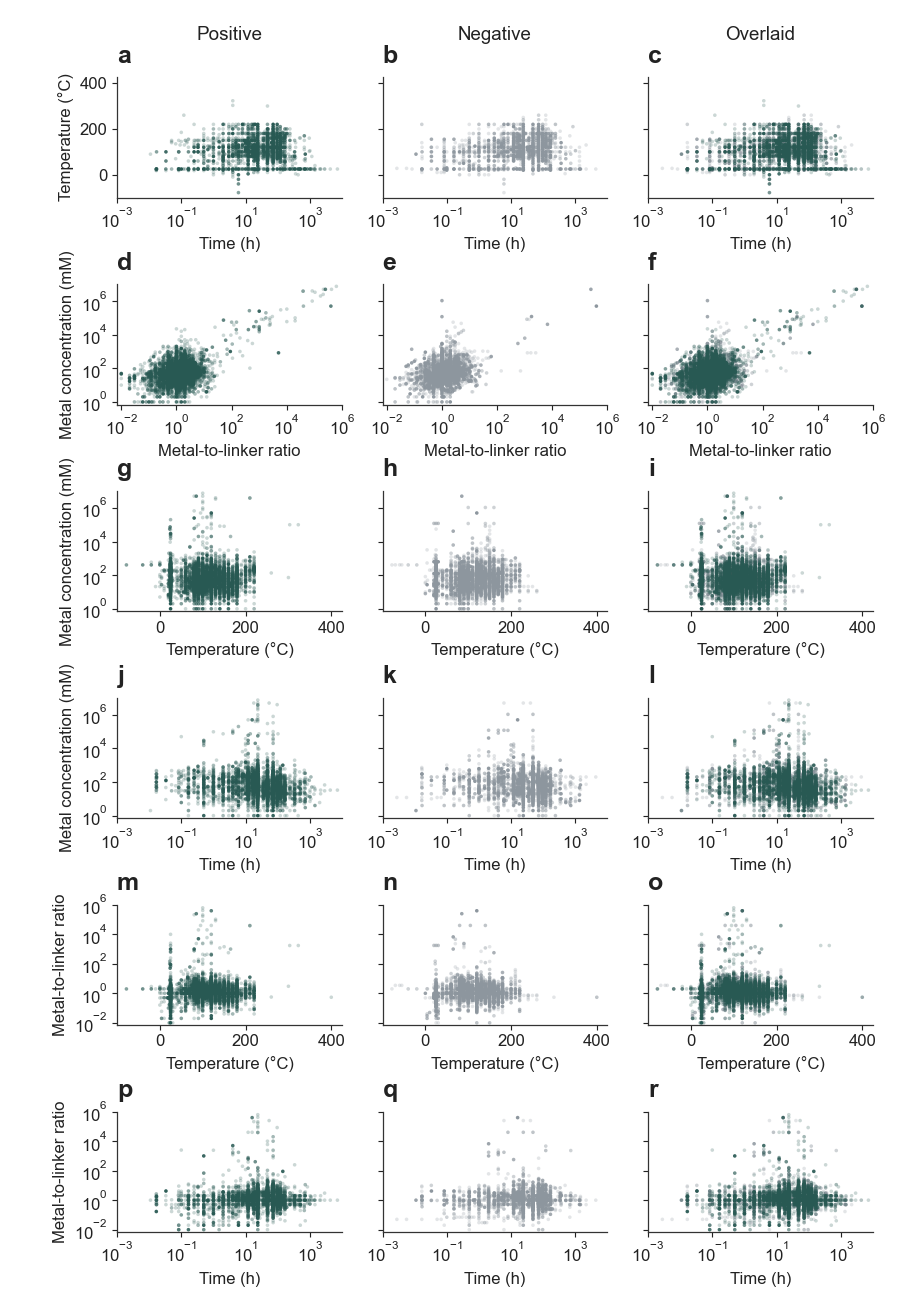

In [2]:
show_plot(plot_coverage(conditions))

Figure D1. Pairwise distributions of synthesis conditions. Columns show positive records, negative records, and their overlay; marker opacity reflects coincident records.

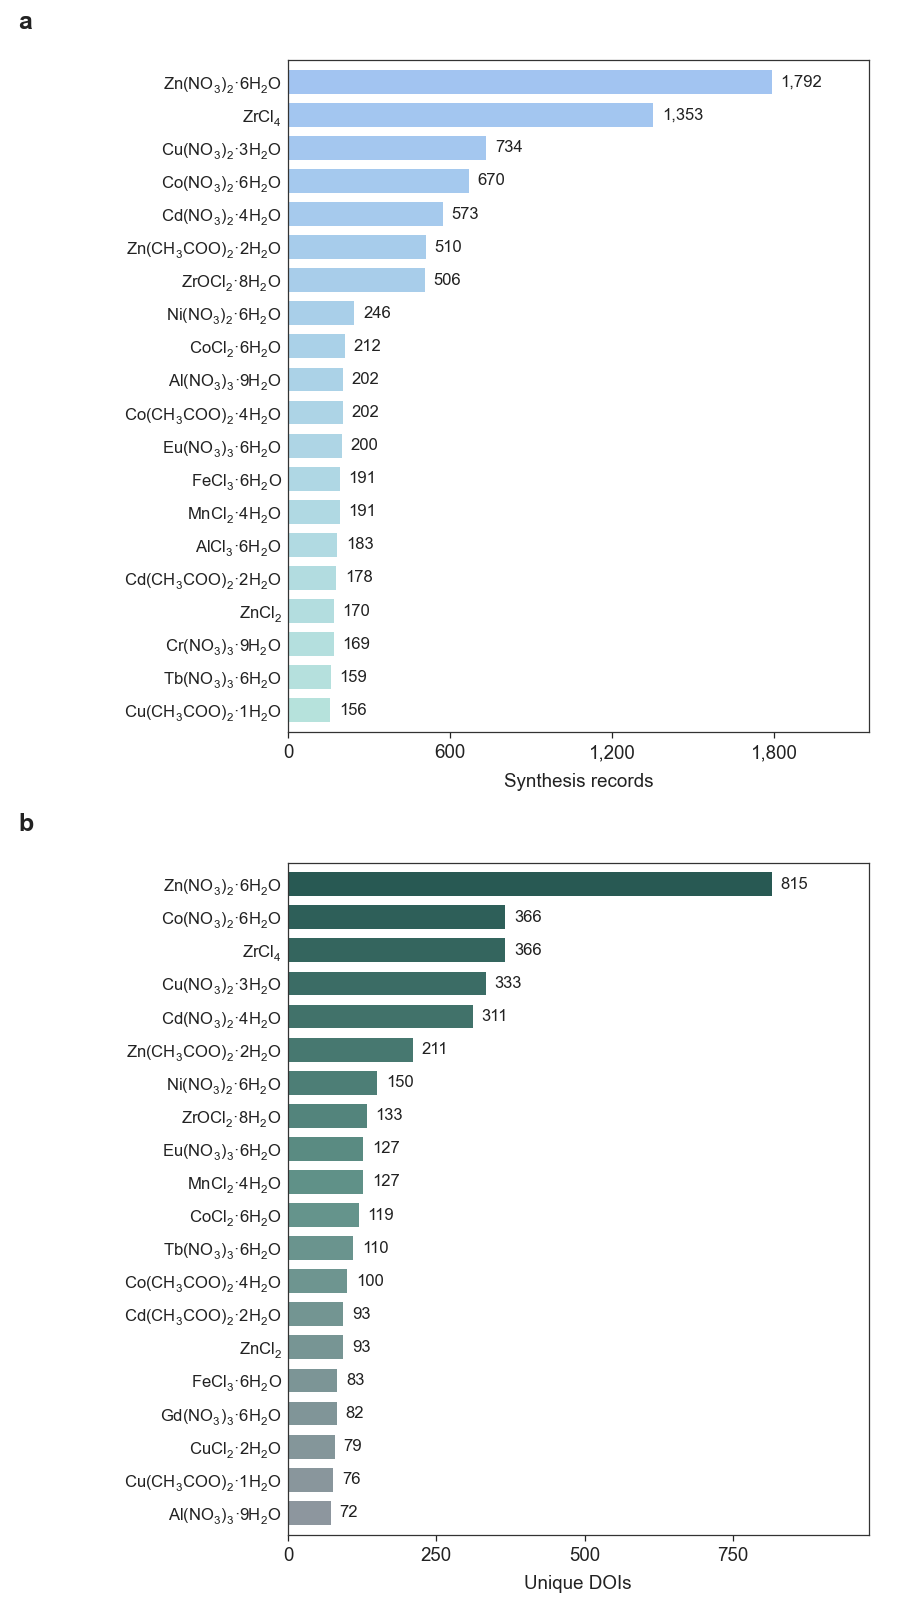

In [3]:
show_plot(plot_category(records, "metal_1", combined=True))

Figure D2. Frequencies of the 20 most common primary metal precursors, with hydrate identities counted separately. a, Synthesis records. b, Unique DOI counts per precursor.

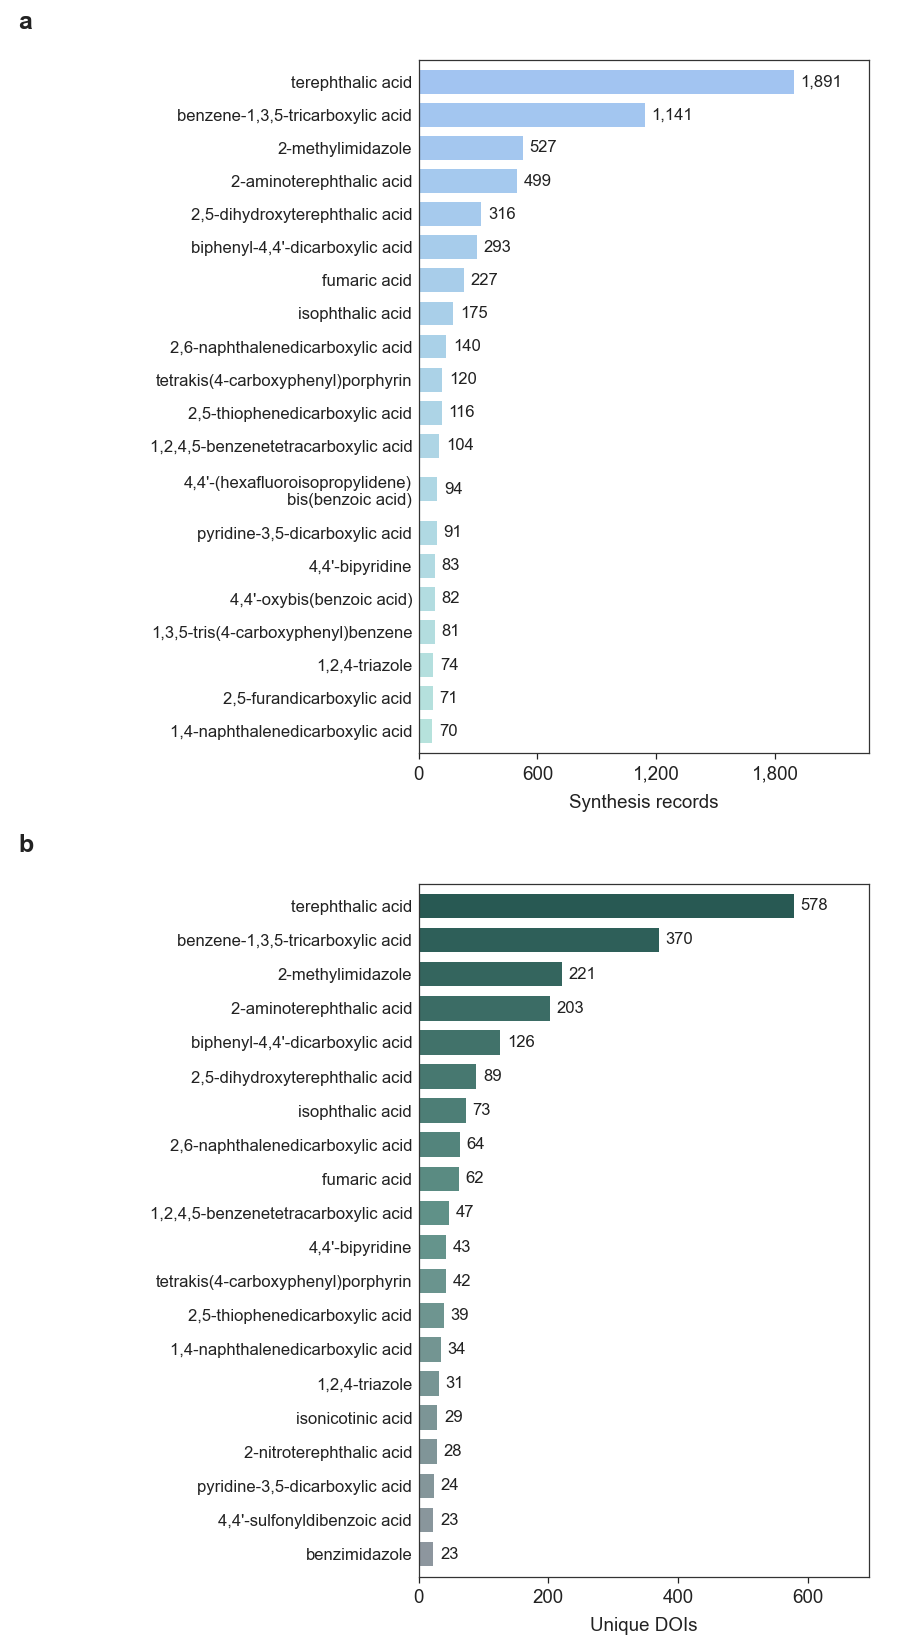

In [4]:
show_plot(plot_category(records, "linker_1", combined=True))

Figure D3. Frequencies of the 20 most common primary linkers. a, Synthesis records. b, Unique DOI counts per linker.

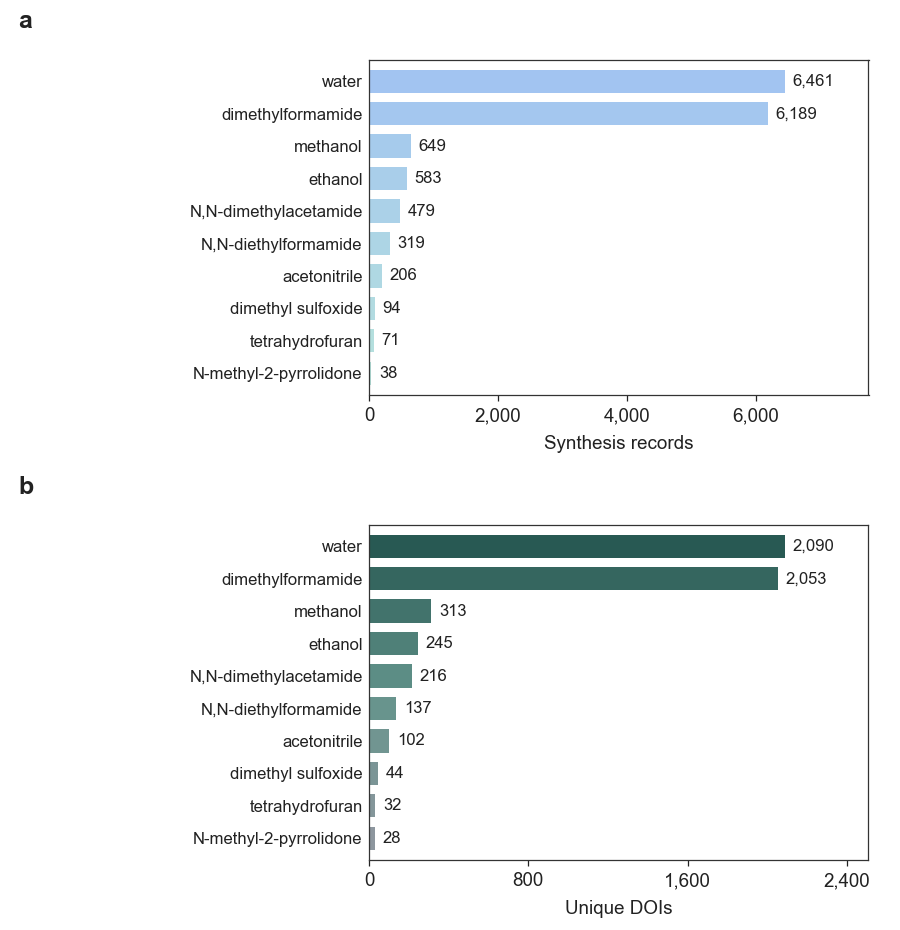

In [5]:
show_plot(plot_category(records, "solvent_main", combined=True))

Figure D4. Frequencies of the 10 most common main solvents. a, Synthesis records. b, Unique DOI counts per solvent.

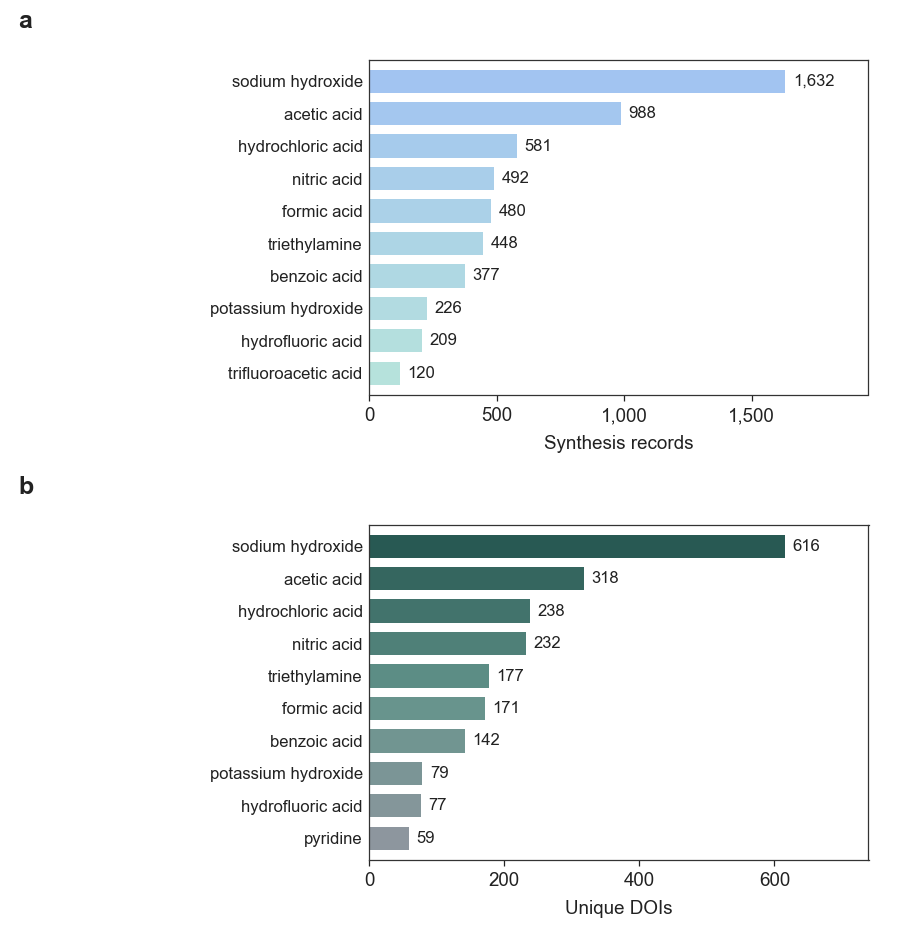

In [6]:
show_plot(plot_category(records, "modulator_1", combined=True))

Figure D5. Frequencies of the 10 most common primary modulators. a, Synthesis records. b, Unique DOI counts per modulator.

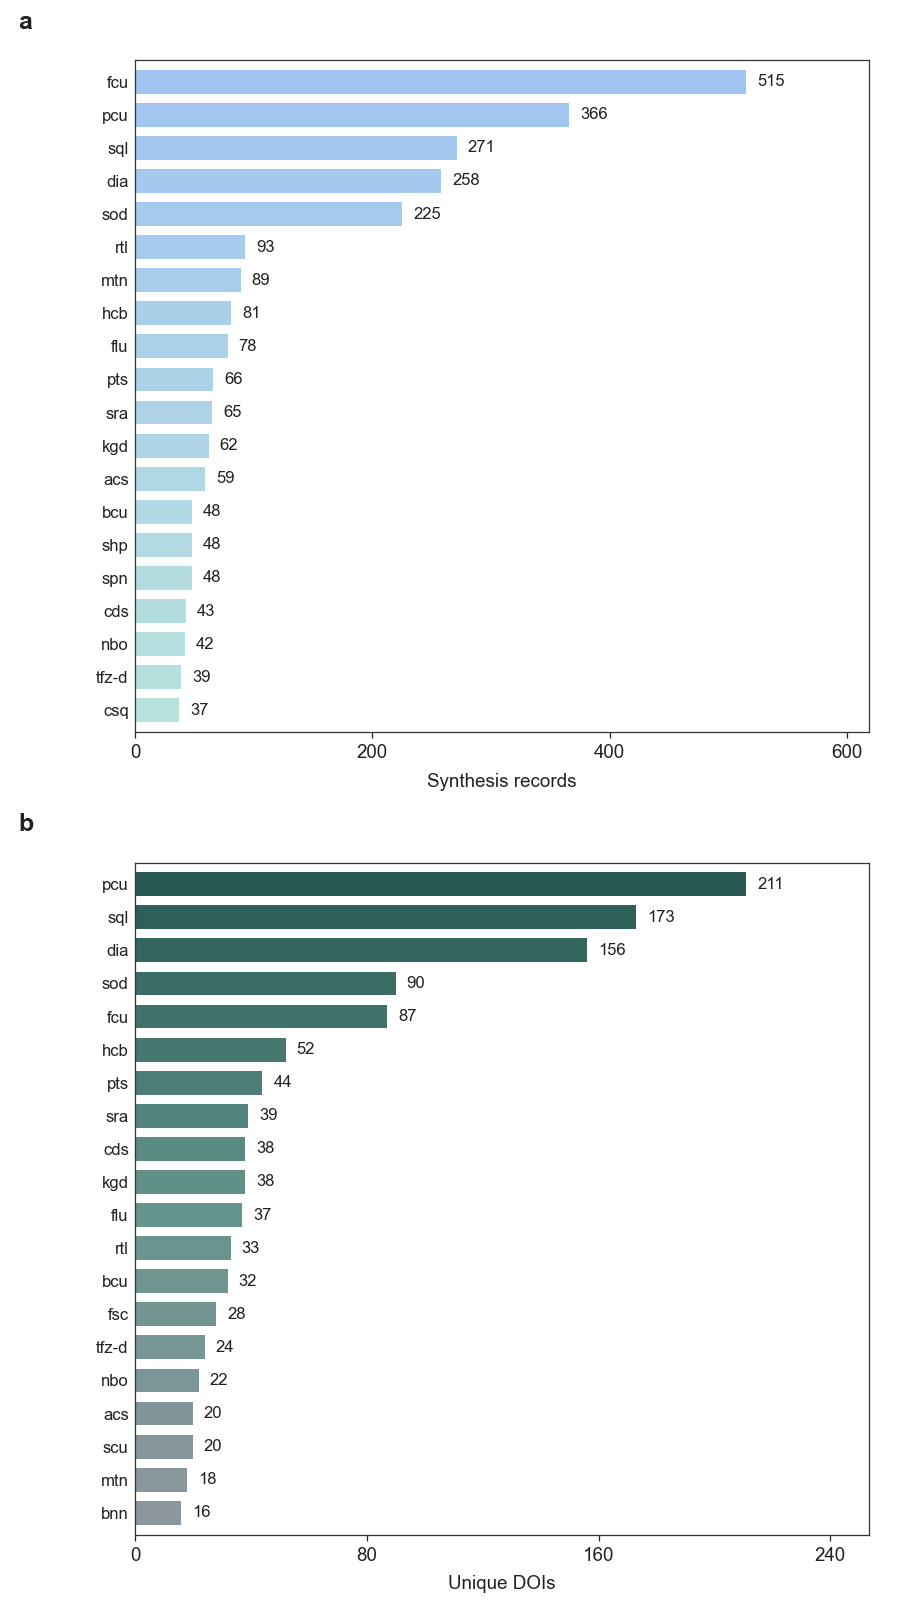

In [7]:
show_plot(plot_category(records, "topology_code", combined=True))

Figure D6. Frequencies of the 20 most common topology codes. a, Synthesis records. b, Unique DOI counts per topology.

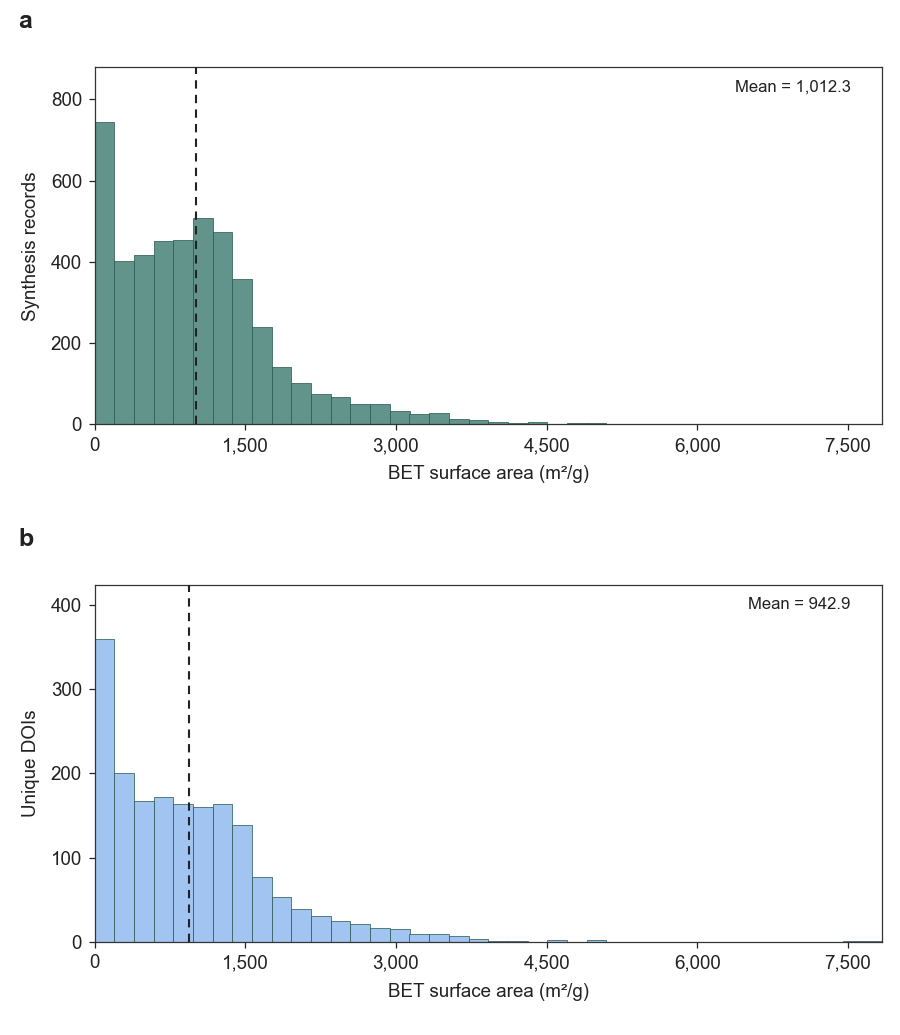

In [8]:
show_plot(plot_property(records, "BET_surface_area_m2g", combined=True))

Figure D7. Histograms of BET surface area. a, Synthesis records. b, Median value per DOI. Dashed lines mark the means.

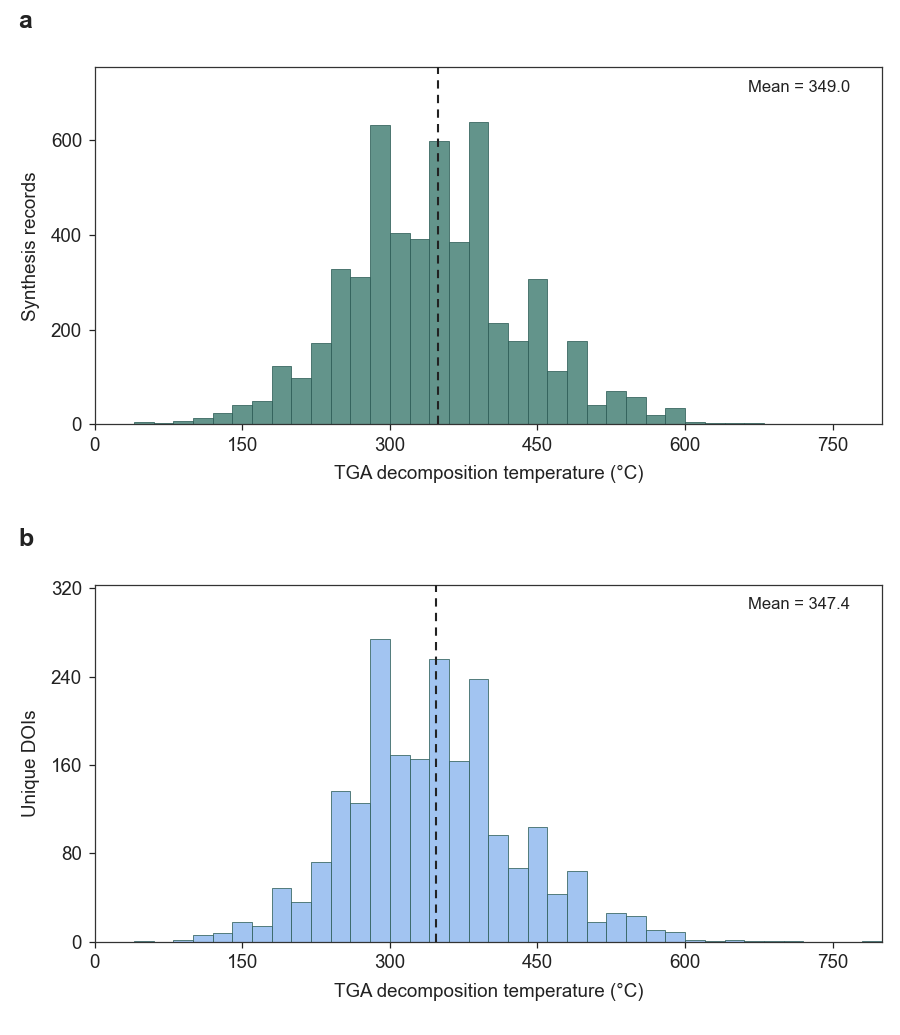

In [9]:
show_plot(plot_property(records, "tga_decomposition_temp_c", combined=True))

Figure D8. Histograms of TGA decomposition temperature. a, Synthesis records. b, Median value per DOI. Dashed lines mark the means.

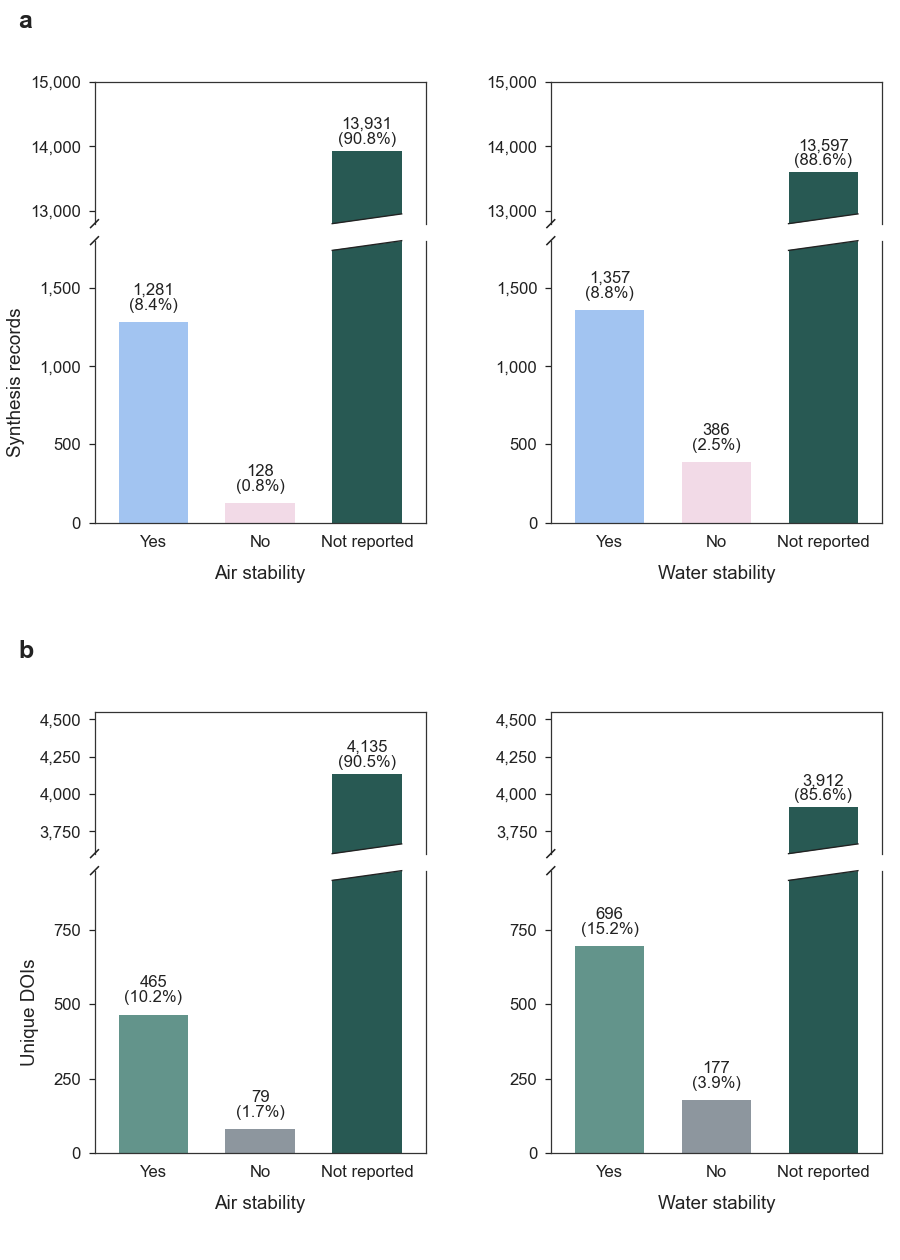

In [10]:
show_plot(plot_stability(records, combined=True))

Figure D9. Air and water stability labels, including Not reported. a, Synthesis records. b, Unique DOI counts per label. Diagonal marks indicate omitted count intervals.

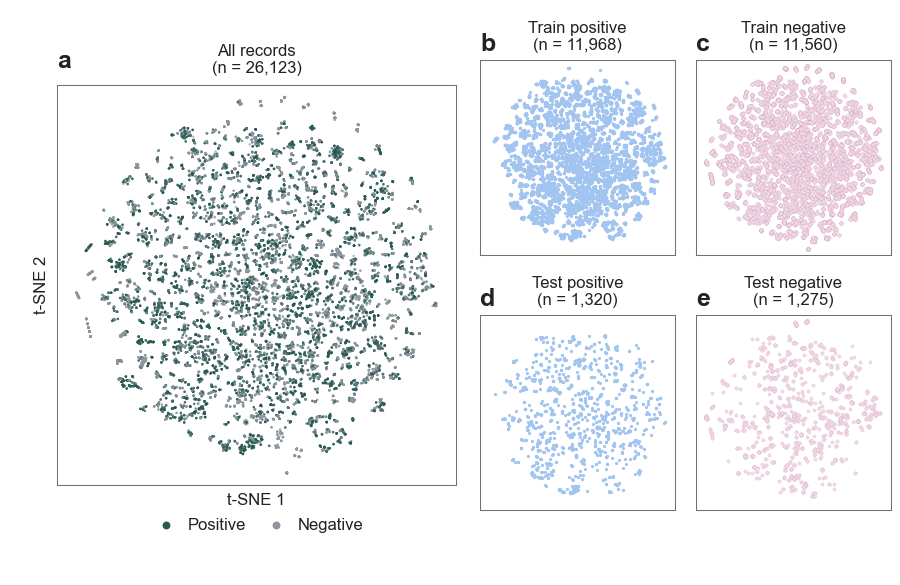

In [11]:
show_plot(plot_embedding(embedding))

Figure D10. t-SNE visualization of synthesis records. a, Combined dataset. b, Positive training records. c, Negative training records. d, Positive test records. e, Negative test records. All panels share coordinates and axis limits.

## Literature coverage

Count bibliography records by publisher and publication period before abstract triage.

In [12]:
PUBLISHER_DATA = ROOT / "docs/triage_figures"
publisher_manifest = json.loads((PUBLISHER_DATA / "provenance.json").read_text(encoding="utf-8"))
for name, expected_hash in publisher_manifest["files"].items():
    assert hashlib.sha256((PUBLISHER_DATA / name).read_bytes()).hexdigest() == expected_hash, name

publisher_summary = summarize_publishers(
    PUBLISHER_DATA / "publisher_source_records.csv", PUBLISHER_DATA / "publisher_name_mapping.csv"
)
actual = {row["Publisher"]: row["Total"] for row in publisher_summary}
assert actual == publisher_manifest["expected_publisher_totals"]
assert sum(actual.values()) == publisher_manifest["record_count"]
with (PUBLISHER_DATA / "publisher_source_records.csv").open(encoding="utf-8", newline="") as handle:
    rows = list(csv.DictReader(handle))
unique_dois = {row["DOI"].strip().lower() for row in rows if row["DOI"].strip()}
assert len(unique_dois) == publisher_manifest["unique_nonempty_doi_count"]
with (ROOT / "data/processed_data/literature_metadata.csv").open(encoding="utf-8-sig", newline="") as handle:
    metadata = list(csv.DictReader(handle))
assert [row["DOI"].strip().lower() for row in rows] == [row["DOI"].strip().lower() for row in metadata]
print(f"{len(rows):,} bibliography records; {len(unique_dois):,} unique DOIs.")

13,773 bibliography records; 13,770 unique DOIs.


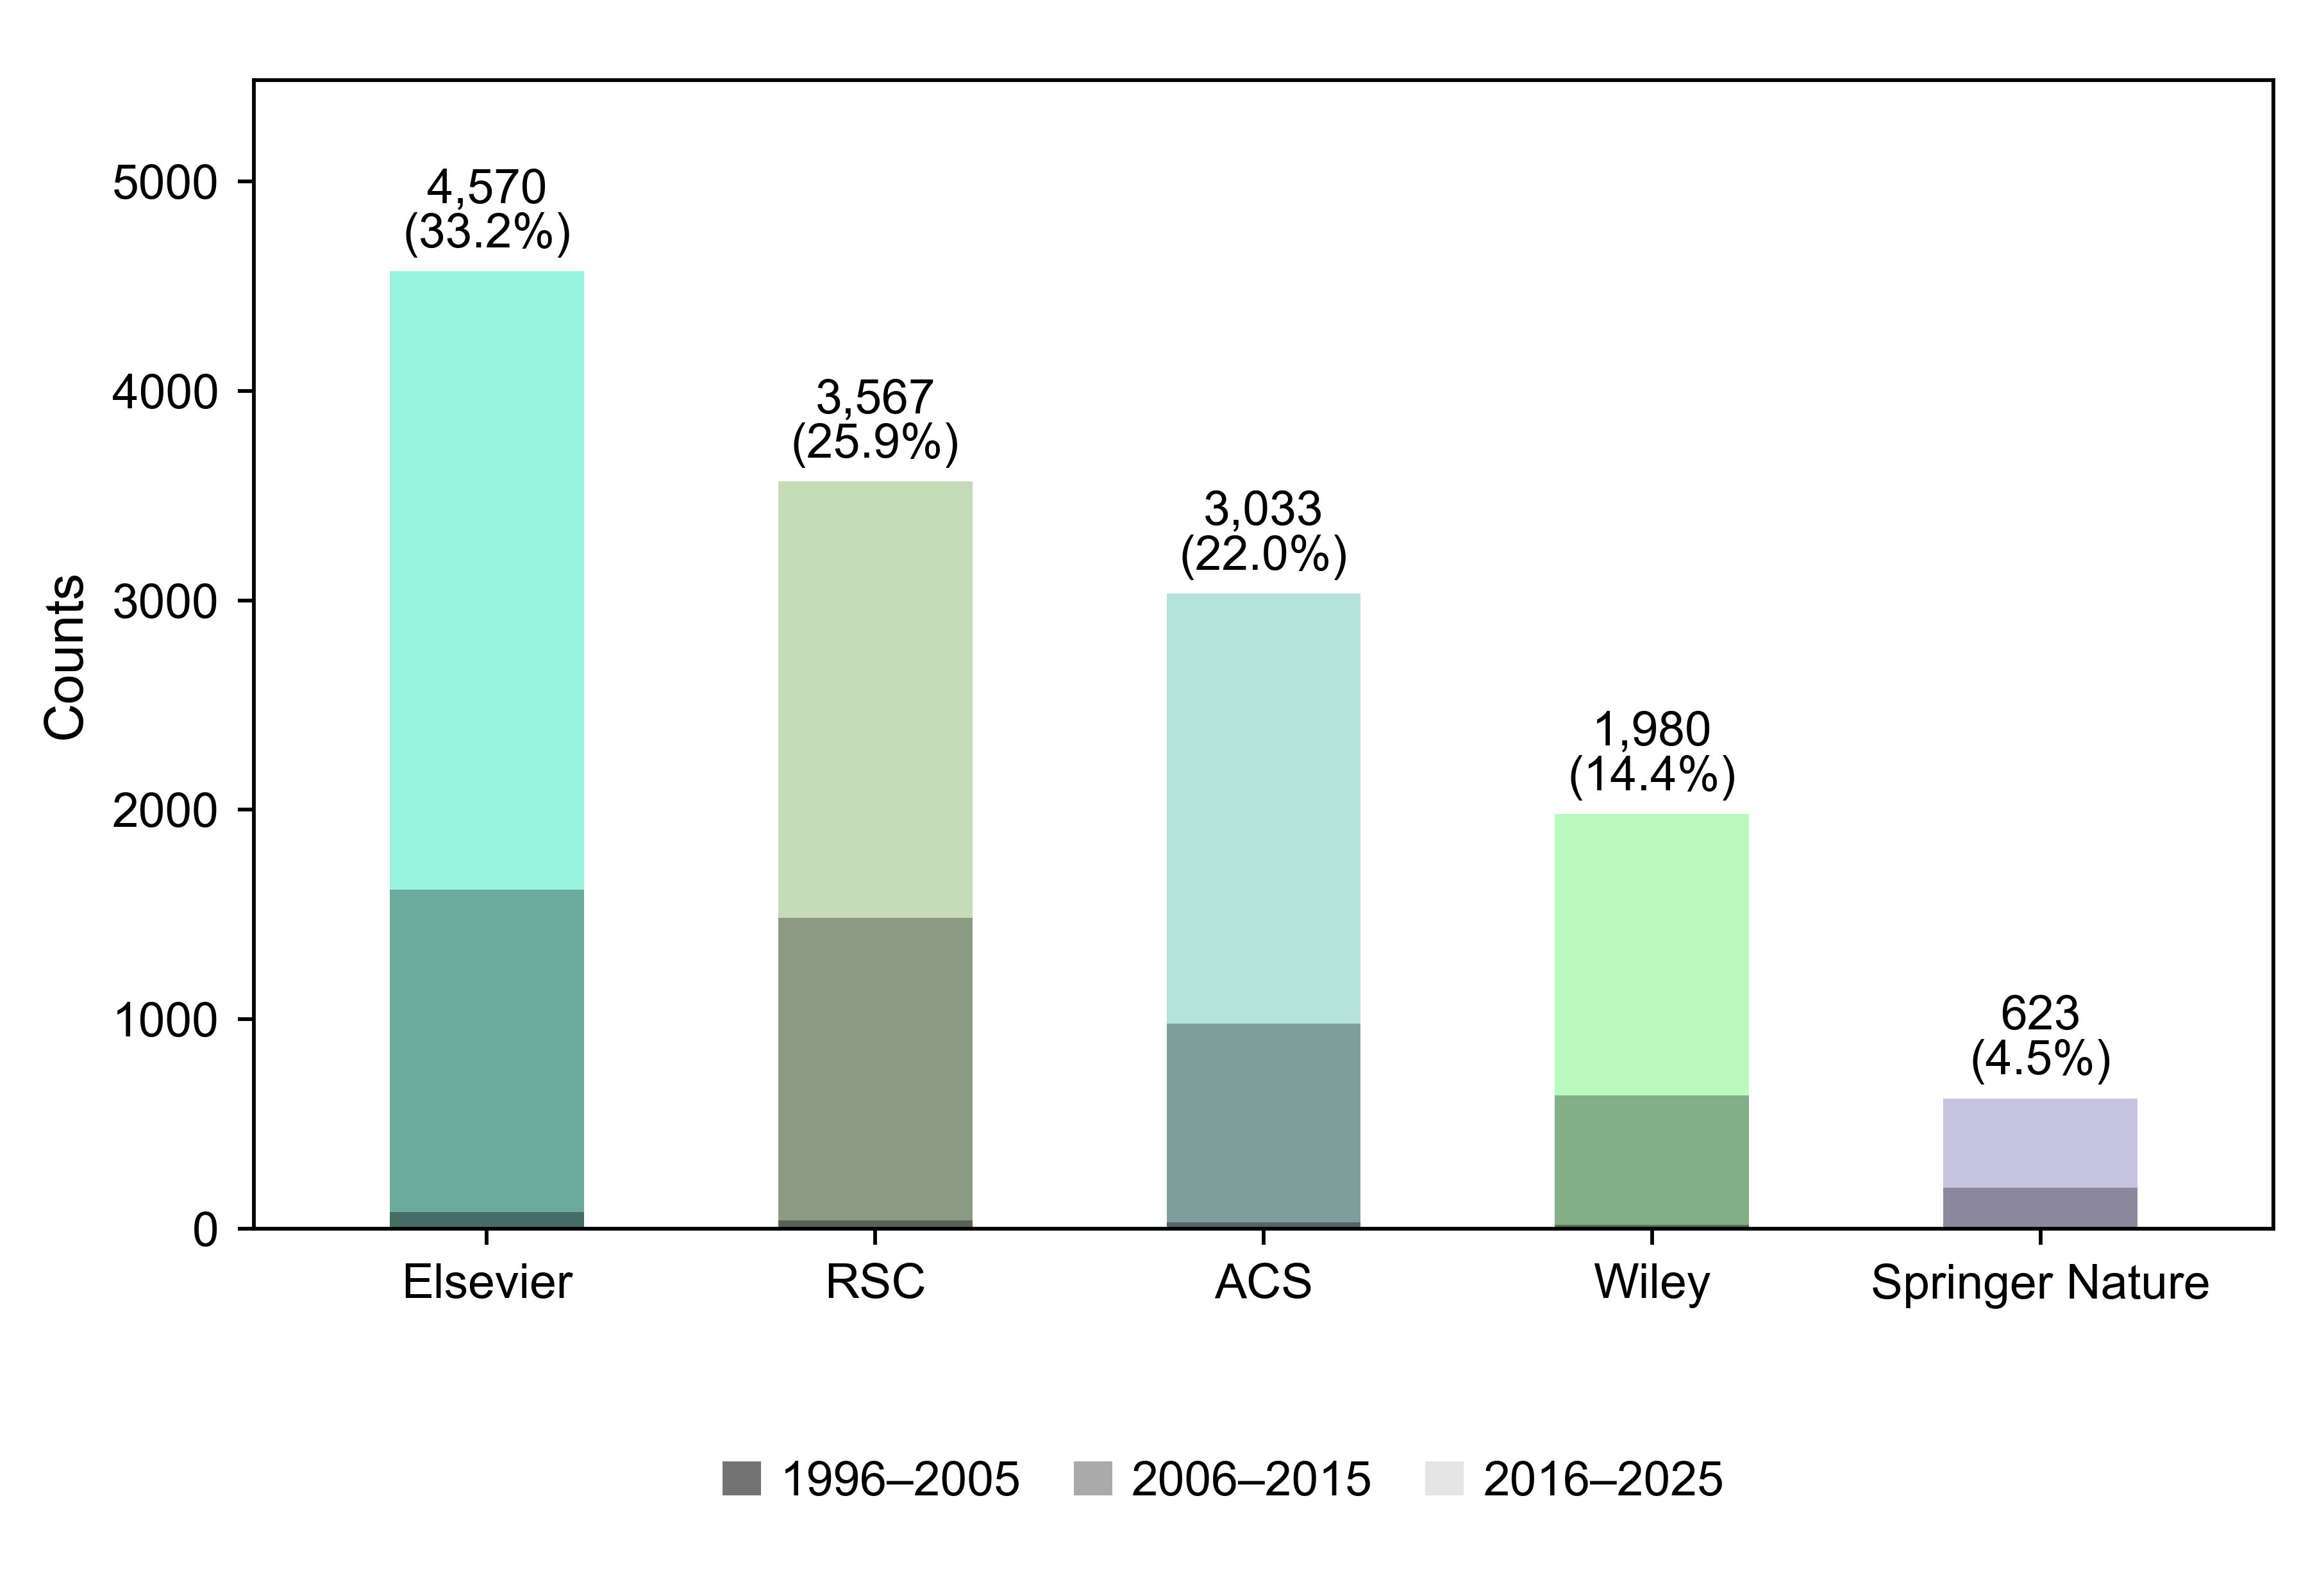

In [13]:
with plt.rc_context(plt.rcParamsDefault):
    publisher_outputs = draw_publisher_coverage(
        publisher_summary, ROOT / "results/dataset_analysis/literature"
    )
display(Image(filename=str(publisher_outputs["png"]), width=720))

Figure D11. Publisher coverage in the literature corpus, grouped by publication period before abstract triage.

## Export

Save PNGs at six inches wide and 600 dpi, with plotting tables and settings.

In [14]:
OUTPUT = ROOT / "results/dataset_analysis"
_, manifest = generate_outputs(records, OUTPUT, dpi=600)
generate_coverage_outputs(conditions, ROOT, OUTPUT, dpi=600)
generate_embedding_outputs(embedding, ROOT, OUTPUT, dpi=600)
print(f"Saved {len(manifest['figures']) + 3} PNGs and plotting tables to results/dataset_analysis/.")

Saved 19 PNGs and plotting tables to results/dataset_analysis/.
